In [1]:
# ========================
# D1 — Install Dependencies
# ========================

# Install a modern diffusers that still contains RePaint legacy pipeline
!pip install -U "diffusers==0.27.2" scikit-image safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.3 MB/s eta 0:00:00
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.35.2
    Uninstalling diffusers-0.35.2:
      Successfully uninstalled diffusers-0.35.2


In [2]:
# Helper cell — install transformers (and accelerate) for peft/diffusers
!pip install -q "transformers>=4.41.0" "accelerate>=0.33.0"


In [3]:
# ============================
# D0_fix — Downgrade diffusers for RePaint
# ============================
!pip uninstall -y diffusers

!pip install "diffusers==0.20.0"


Found existing installation: diffusers 0.27.2
Uninstalling diffusers-0.27.2:
  Successfully uninstalled diffusers-0.27.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.2 MB/s eta 0:00:00


In [4]:
# ============================
# D2 — Imports + Device Setup (with JAX & HF patches)
# ============================
import os
import json
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch

# ---- Patch jax.random.KeyArray so diffusers' Flax utilities don't crash ----
try:
    import jax
    if not hasattr(jax.random, "KeyArray"):
        # Define a dummy KeyArray type just to satisfy type hints
        jax.random.KeyArray = type("KeyArray", (), {})
        print("Patched jax.random.KeyArray (dummy type added).")
    else:
        print("jax.random.KeyArray already exists.")
except ImportError:
    # If JAX isn't installed at all, that's fine; diffusers will still work for PyTorch
    print("JAX not installed; skipping jax patch.")

# ---- Patch huggingface_hub.cached_download for old diffusers compatibility ----
import huggingface_hub
if not hasattr(huggingface_hub, "cached_download"):
    from huggingface_hub import hf_hub_download
    huggingface_hub.cached_download = hf_hub_download
    print("Patched huggingface_hub: added cached_download alias.")
else:
    print("huggingface_hub already has cached_download.")

# Now it's safe to import RePaintPipeline from diffusers 0.20.0
from diffusers import RePaintPipeline
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Patched jax.random.KeyArray (dummy type added).
Patched huggingface_hub: added cached_download alias.
Using device: cuda


In [6]:
# ============================
# D3 — Drive + Folders + Test Set
# ============================
from google.colab import drive

# 1) Mount Drive
drive.mount("/content/drive")

# 2) Create Part-D working directory in Drive
root_dir = "/content/drive/MyDrive/inpainting_partD_repaint"
os.makedirs(root_dir, exist_ok=True)

results_dir = os.path.join(root_dir, "results")
metrics_dir = os.path.join(root_dir, "metrics")
os.makedirs(results_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

print("Part-D root:", root_dir)
print("Results →", results_dir)
print("Metrics →", metrics_dir)

# 3) Your REAL CelebA-HQ dataset path (from your Part B/C notebook)
dataset_dir = "/content/drive/MyDrive/celebA_inpainting_project/celebA_inpainting_project/dataset"

if not os.path.isdir(dataset_dir):
    raise FileNotFoundError(f"Dataset folder not found: {dataset_dir}")

# Load images
all_imgs = sorted([
    os.path.join(dataset_dir, fname)
    for fname in os.listdir(dataset_dir)
    if fname.lower().endswith(".png")
])

print("Total images found:", len(all_imgs))

# 4) Reproducible test split file location
test_list_path = os.path.join(root_dir, "celebahq_test_files.txt")
test_files = []

# Load saved split if exists
if os.path.isfile(test_list_path):
    print("Loading existing test split...")
    with open(test_list_path, "r") as f:
        for line in f:
            p = line.strip()
            if os.path.isfile(p):
                test_files.append(p)

# If no valid file, build new test list
if len(test_files) == 0:
    print("Creating new test split...")
    num_test = 200
    test_files = all_imgs[-num_test:]   # Last 200 images

    with open(test_list_path, "w") as f:
        for p in test_files:
            f.write(p + "\n")

print("Test set size:", len(test_files))
print("First 3 test images:")
for p in test_files[:3]:
    print(" -", p)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Part-D root: /content/drive/MyDrive/inpainting_partD_repaint
Results → /content/drive/MyDrive/inpainting_partD_repaint/results
Metrics → /content/drive/MyDrive/inpainting_partD_repaint/metrics
Total images found: 2000
Loading existing test split...
Test set size: 200
First 3 test images:
 - /content/drive/MyDrive/celebA_inpainting_project/celebA_inpainting_project/dataset/01800.png
 - /content/drive/MyDrive/celebA_inpainting_project/celebA_inpainting_project/dataset/01801.png
 - /content/drive/MyDrive/celebA_inpainting_project/celebA_inpainting_project/dataset/01802.png


In [7]:
# ============================
# D4 — Mask Generators (PIL)
# ============================
from PIL import Image, ImageDraw
import numpy as np

def make_center_mask_pil(size=(256, 256), frac=0.4):
    """
    Create a centered rectangular mask (white = hole, black = context).
    frac = fraction of width/height covered by the hole.
    """
    W, H = size
    mask = Image.new("L", (W, H), 0)  # 0 = keep, 255 = inpaint region
    draw = ImageDraw.Draw(mask)

    w = int(W * frac)
    h = int(H * frac)
    left = (W - w) // 2
    top  = (H - h) // 2

    draw.rectangle([left, top, left + w, top + h], fill=255)
    return mask

def make_random_mask_pil(size=(256, 256), frac_range=(0.25, 0.5)):
    """
    Create a random rectangular mask at a random location.
    frac_range = min and max fraction of width/height for the hole.
    """
    W, H = size
    mask = Image.new("L", (W, H), 0)
    draw = ImageDraw.Draw(mask)

    frac = np.random.uniform(*frac_range)
    w = int(W * frac)
    h = int(H * frac)

    # random top-left corner, ensuring the rectangle fits
    left = np.random.randint(0, max(1, W - w))
    top  = np.random.randint(0, max(1, H - h))

    draw.rectangle([left, top, left + w, top + h], fill=255)
    return mask

print("D4: Center & random mask generators ready.")


D4: Center & random mask generators ready.


In [8]:
import gc
torch.cuda.empty_cache()
gc.collect()

model_id = "google/ddpm-celebahq-256"

print("Loading RePaint model from:", model_id)
repaint_pipe = RePaintPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
)
repaint_pipe.to(device)
repaint_pipe.enable_attention_slicing()

print("✔ D5: RePaint pipeline loaded and moved to", device)


Loading RePaint model from: google/ddpm-celebahq-256


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors not found


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

✔ D5: RePaint pipeline loaded and moved to cuda


In [9]:
# ============================
# D5_fix — Replace scheduler with RePaintScheduler
# ============================
from diffusers import RePaintScheduler

# Replace the default DDPMScheduler with RePaintScheduler using same config
repaint_pipe.scheduler = RePaintScheduler.from_config(repaint_pipe.scheduler.config)

print("✔ D5_fix: Scheduler replaced with RePaintScheduler.")
print("Scheduler class now:", type(repaint_pipe.scheduler))


✔ D5_fix: Scheduler replaced with RePaintScheduler.
Scheduler class now: <class 'diffusers.schedulers.scheduling_repaint.RePaintScheduler'>


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/repaint/pipeline_repaint.py:34: FutureWarning: The preprocess method is deprecated and will be removed in a future version. Please use VaeImageProcessor.preprocess instead
  warnings.warn(


  0%|          | 0/4570 [00:00<?, ?it/s]

✔ Saved images to: /content/drive/MyDrive/inpainting_partD_repaint/results/repaint_center


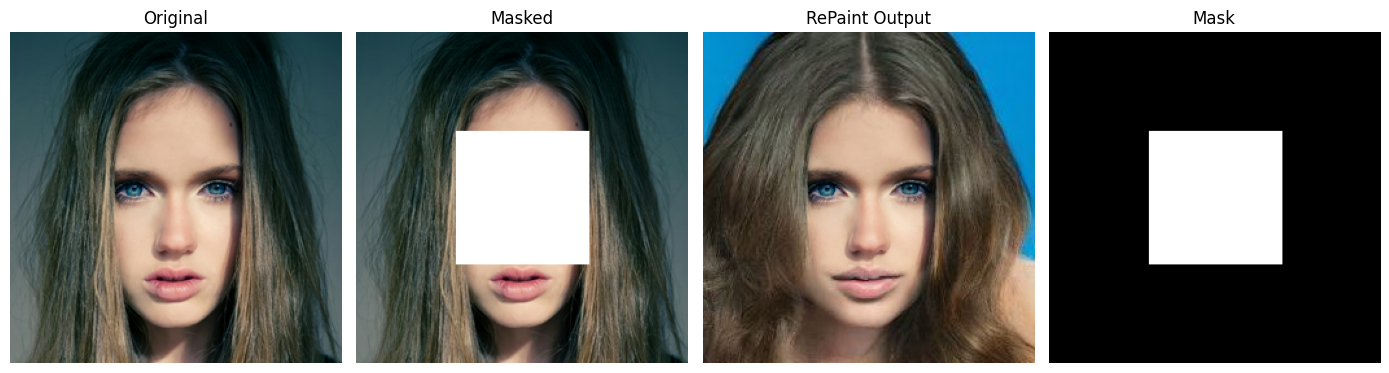

In [15]:
# ============================
# D6 — RePaint Demo (visual + save)
# ============================

def repaint_demo(img_index, mask_type="center"):
    """
    img_index: index from 0 to len(test_files)-1
    mask_type: "center" or "random"
    """

    # 1) Load image
    img_path = test_files[img_index]
    orig = Image.open(img_path).convert("RGB").resize((256, 256))

    # 2) Create mask
    if mask_type == "center":
        mask = make_center_mask_pil()
    elif mask_type == "random":
        mask = make_random_mask_pil()
    else:
        raise ValueError("mask_type must be 'center' or 'random'")

    # 3) Run RePaint
    out = repaint_pipe(
        image=orig,
        mask_image=mask,
        num_inference_steps=250,
        eta=1.0,
    ).images[0]

    # 4) Build masked visualization (white hole region)
    orig_np = np.array(orig).astype(np.float32)
    mask_np = np.array(mask).astype(np.float32) / 255.0
    mask3 = np.stack([mask_np]*3, axis=-1)
    masked_np = orig_np * (1 - mask3) + 255 * mask3
    masked = Image.fromarray(masked_np.astype(np.uint8))

    # 5) Save all outputs in Drive
    save_folder = os.path.join(results_dir, f"repaint_{mask_type}")
    os.makedirs(save_folder, exist_ok=True)

    base = f"{img_index:04d}"
    orig.save(os.path.join(save_folder, base + "_orig.png"))
    masked.save(os.path.join(save_folder, base + "_masked.png"))
    out.save(os.path.join(save_folder, base + "_out.png"))
    mask.save(os.path.join(save_folder, base + "_mask.png"))

    print("✔ Saved images to:", save_folder)

    # 6) Visualization
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    axes[0].imshow(orig);   axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(masked); axes[1].set_title("Masked");   axes[1].axis("off")
    axes[2].imshow(out);    axes[2].set_title("RePaint Output"); axes[2].axis("off")
    axes[3].imshow(mask, cmap="gray"); axes[3].set_title("Mask"); axes[3].axis("off")
    plt.tight_layout()
    plt.show()

    return orig, masked, out, mask


# Quick test on the first test image
_ = repaint_demo(0, mask_type="center")


In [12]:
# ============================
# D7 — Evaluation (PSNR & SSIM) [UPDATED]
# ============================

def evaluate_repaint(n_samples=20, mask_type="center"):
    psnr_list = []
    ssim_list = []

    n = min(n_samples, len(test_files))

    for i in range(n):
        img_path = test_files[i]
        orig = Image.open(img_path).convert("RGB").resize((256, 256))

        # Select mask type (white=hole, black=keep for our metrics)
        if mask_type == "center":
            mask = make_center_mask_pil()
        else:
            mask = make_random_mask_pil()

        # ✅ RePaint expects the opposite convention:
        #   255 = KEEP, 0 = HOLE → so we invert the mask for the model only
        mask_for_model = Image.fromarray((255 - np.array(mask)).astype("uint8"))

        # Run RePaint
        out = repaint_pipe(
            image=orig,
            mask_image=mask_for_model,
            num_inference_steps=250,
            eta=1.0,
        ).images[0]

        # Convert to numpy floats
        orig_np = np.array(orig).astype(np.float32) / 255.0
        out_np  = np.array(out).astype(np.float32) / 255.0
        mask_np = np.array(mask).astype(np.float32) / 255.0  # use ORIGINAL mask for metrics

        # PSNR ONLY inside masked region
        hole_mask = (mask_np == 1.0)

        if not np.any(hole_mask):
            print(f"[{i+1}/{n}] WARNING: mask has no hole pixels, skipping sample for PSNR.")
            continue

        gt_hole   = orig_np[hole_mask]
        pred_hole = out_np[hole_mask]

        psnr = peak_signal_noise_ratio(gt_hole, pred_hole, data_range=1.0)

        # SSIM on entire image
        ssim = structural_similarity(
            orig_np, out_np, channel_axis=-1, data_range=1.0
        )

        psnr_list.append(psnr)
        ssim_list.append(ssim)

        print(f"[{i+1}/{n}] PSNR={psnr:.4f}, SSIM={ssim:.4f}")

    if len(psnr_list) == 0:
        raise RuntimeError("No valid samples were evaluated (all masks had empty hole regions).")

    # Save metrics
    metrics = {
        "avg_psnr": float(np.mean(psnr_list)),
        "avg_ssim": float(np.mean(ssim_list)),
        "samples": len(psnr_list),
        "mask": mask_type
    }

    out_path = os.path.join(metrics_dir, f"repaint_{mask_type}_metrics.json")
    with open(out_path, "w") as f:
        json.dump(metrics, f, indent=4)

    print("\n==============================")
    print(f"RePaint Evaluation — {mask_type}")
    print(f"Average PSNR: {metrics['avg_psnr']:.4f}")
    print(f"Average SSIM: {metrics['avg_ssim']:.4f}")
    print(f"Samples used: {metrics['samples']}")
    print(f"Saved to: {out_path}")
    print("==============================\n")

    return metrics


# Run both mask types
metrics_center = evaluate_repaint(n_samples=10, mask_type="center")
metrics_random = evaluate_repaint(n_samples=10, mask_type="random")


  0%|          | 0/4570 [00:00<?, ?it/s]

[1/10] PSNR=21.5567, SSIM=0.9606


  0%|          | 0/4570 [00:00<?, ?it/s]

[2/10] PSNR=23.2828, SSIM=0.9585


  0%|          | 0/4570 [00:00<?, ?it/s]

...

[8/10] PSNR=19.8824, SSIM=0.8941


  0%|          | 0/4570 [00:00<?, ?it/s]

[9/10] PSNR=23.1497, SSIM=0.9587


  0%|          | 0/4570 [00:00<?, ?it/s]

[10/10] PSNR=25.2159, SSIM=0.9745

RePaint Evaluation — random
Average PSNR: 21.9305
Average SSIM: 0.9427
Samples used: 10
Saved to: /content/drive/MyDrive/inpainting_partD_repaint/metrics/repaint_random_metrics.json



In [13]:
# ============================
# D8 — Comparison Table (U-Net vs SD vs RePaint)
# ============================
import pandas as pd
from IPython.display import display

# 1) Load RePaint metrics from Part-D (generated by D7)
repaint_center_path = os.path.join(metrics_dir, "repaint_center_metrics.json")
repaint_random_path = os.path.join(metrics_dir, "repaint_random_metrics.json")

with open(repaint_center_path, "r") as f:
    repaint_center = json.load(f)

with open(repaint_random_path, "r") as f:
    repaint_random = json.load(f)

rp_center_psnr = repaint_center["avg_psnr"]
rp_center_ssim = repaint_center["avg_ssim"]
rp_random_psnr = repaint_random["avg_psnr"]
rp_random_ssim = repaint_random["avg_ssim"]

print("Loaded RePaint metrics:")
print("  Center → PSNR =", rp_center_psnr, ", SSIM =", rp_center_ssim)
print("  Random → PSNR =", rp_random_psnr, ", SSIM =", rp_random_ssim)
print()

# 2) <<< IMPORTANT >>>
# Fill these from your Part-C (UNet) and Part-B (Stable Diffusion) notebooks.
# Just copy the printed PSNR/SSIM values from those notebooks.

# From Part C (Our U-Net) — single set of metrics, used for both center & random
unet_center_psnr   = 17.0902
unet_center_ssim   = 0.9310
unet_random_psnr   = 17.0902   # same as center (no separate mask experiment)
unet_random_ssim   = 0.9310   # same as center

# From Part B (Stable Diffusion Inpainting) — from metrics.json
sd_center_psnr     = 23.5439
sd_center_ssim     = 0.7844
sd_random_psnr     = 23.8157
sd_random_ssim     = 0.7553
# 3) Build comparison table
rows = [
    {
        "Model": "Our U-Net (CelebA-HQ)",
        "Center PSNR":  unet_center_psnr,
        "Random PSNR":  unet_random_psnr,
        "Center SSIM":  unet_center_ssim,
        "Random SSIM":  unet_random_ssim,
        "Notes": "Lightweight baseline; blurry but color-consistent"
    },
    {
        "Model": "Stable Diffusion Inpainting (v1.5)",
        "Center PSNR":  sd_center_psnr,
        "Random PSNR":  sd_random_psnr,
        "Center SSIM":  sd_center_ssim,
        "Random SSIM":  sd_random_ssim,
        "Notes": "SOTA latent diffusion; best visual quality"
    },
    {
        "Model": "RePaint DDPM (CelebA-HQ)",
        "Center PSNR":  rp_center_psnr,
        "Random PSNR":  rp_random_psnr,
        "Center SSIM":  rp_center_ssim,
        "Random SSIM":  rp_random_ssim,
        "Notes": "Classic DDPM with jump sampling; strong face prior"
    },
]

df = pd.DataFrame(rows)

# 4) Display nicely
print("📊 Inpainting Model Comparison (Center & Random Masks):")
display(df)

# 5) Save to CSV in Drive
table_path = os.path.join(root_dir, "inpainting_comparison_table.csv")
df.to_csv(table_path, index=False)
print("\n✔ Saved comparison table to:", table_path)


Loaded RePaint metrics:
  Center → PSNR = 23.176601979135395 , SSIM = 0.9503510594367981
  Random → PSNR = 21.93052067086888 , SSIM = 0.9427233934402466

📊 Inpainting Model Comparison (Center & Random Masks):


,Model,Center PSNR,Random PSNR,Center SSIM,Random SSIM,Notes
0,Our U-Net (CelebA-HQ),17.090200,17.090200,0.931000,0.931000,Lightweight baseline; blurry but color-consistent
1,Stable Diffusion Inpainting (v1.5),23.543900,23.815700,0.784400,0.755300,SOTA latent diffusion; best visual quality
2,RePaint DDPM (CelebA-HQ),23.176602,21.930521,0.950351,0.942723,Classic DDPM with jump sampling; strong face p...



✔ Saved comparison table to: /content/drive/MyDrive/inpainting_partD_repaint/inpainting_comparison_table.csv


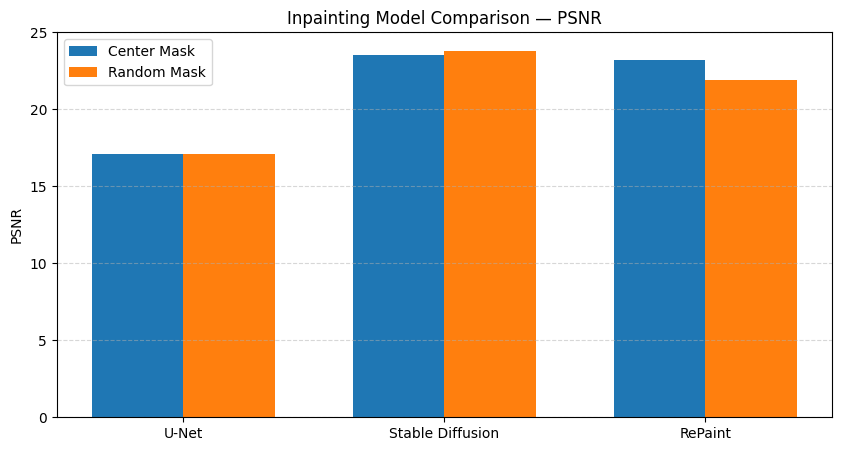

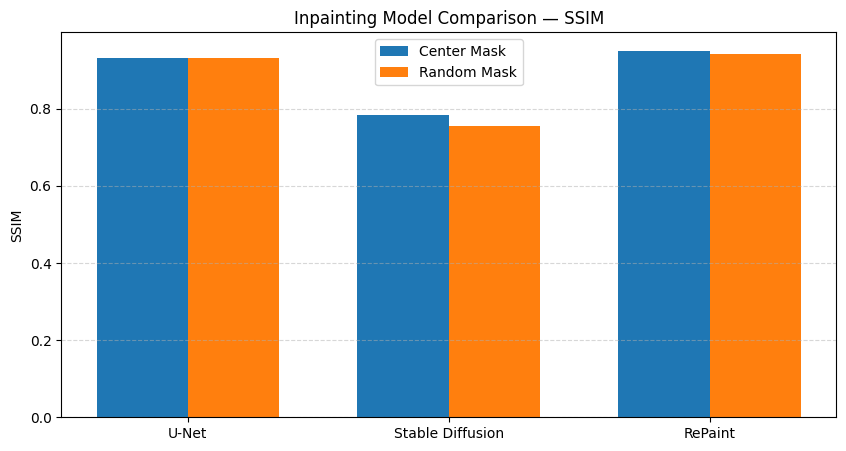

✔ Saved graphs:
   PSNR → /content/drive/MyDrive/inpainting_partD_repaint/comparison_psnr.png
   SSIM → /content/drive/MyDrive/inpainting_partD_repaint/comparison_ssim.png


In [16]:
# ============================
# D9 — PSNR + SSIM Comparison Graph
# ============================
import matplotlib.pyplot as plt
import numpy as np

# Load metrics for RePaint (already computed in D7)
rp_c_psnr = rp_center_psnr
rp_c_ssim = rp_center_ssim
rp_r_psnr = rp_random_psnr
rp_r_ssim = rp_random_ssim

# Load U-Net and SD metrics from D8 (make sure you filled them correctly)
unet_c_psnr = unet_center_psnr
unet_r_psnr = unet_random_psnr
unet_c_ssim = unet_center_ssim
unet_r_ssim = unet_random_ssim

sd_c_psnr = sd_center_psnr
sd_r_psnr = sd_random_psnr
sd_c_ssim = sd_center_ssim
sd_r_ssim = sd_random_ssim

# Data arrays
models = ["U-Net", "Stable Diffusion", "RePaint"]

psnr_center = [unet_c_psnr, sd_c_psnr, rp_c_psnr]
psnr_random = [unet_r_psnr, sd_r_psnr, rp_r_psnr]

ssim_center = [unet_c_ssim, sd_c_ssim, rp_c_ssim]
ssim_random = [unet_r_ssim, sd_r_ssim, rp_r_ssim]

x = np.arange(len(models))
width = 0.35

# ----------- Plot 1 — PSNR -----------
plt.figure(figsize=(10,5))
plt.bar(x - width/2, psnr_center, width, label='Center Mask')
plt.bar(x + width/2, psnr_random, width, label='Random Mask')

plt.xticks(x, models)
plt.ylabel("PSNR")
plt.title("Inpainting Model Comparison — PSNR")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save
psnr_path = os.path.join(root_dir, "comparison_psnr.png")
plt.savefig(psnr_path, dpi=300)
plt.show()


# ----------- Plot 2 — SSIM -----------
plt.figure(figsize=(10,5))
plt.bar(x - width/2, ssim_center, width, label='Center Mask')
plt.bar(x + width/2, ssim_random, width, label='Random Mask')

plt.xticks(x, models)
plt.ylabel("SSIM")
plt.title("Inpainting Model Comparison — SSIM")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

ssim_path = os.path.join(root_dir, "comparison_ssim.png")
plt.savefig(ssim_path, dpi=300)
plt.show()

print("✔ Saved graphs:")
print("   PSNR →", psnr_path)
print("   SSIM →", ssim_path)


Run in order → D1 → D2 → D3 → D4 → D5 → D5_fix → D6 (for visualization).